## Task

In the following, an artificial data set was created using the function `make_blobs()`. It consists of three subareas, each of which was created by a Gaussian distribution with a different standard deviation. For each point it is known by which of the three Gaussian distributions it has been created. This class information is stored in `y`.

Visualize the actual membership, the cluster membership using K-Means and a classification result using Logistic Regression. Explain the observed effects.

In [1]:
from sklearn import datasets
X,y = datasets.make_blobs(n_samples=1500,
                          cluster_std=[1.0, 2.5, 0.5],
                          random_state=170)

/root/venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


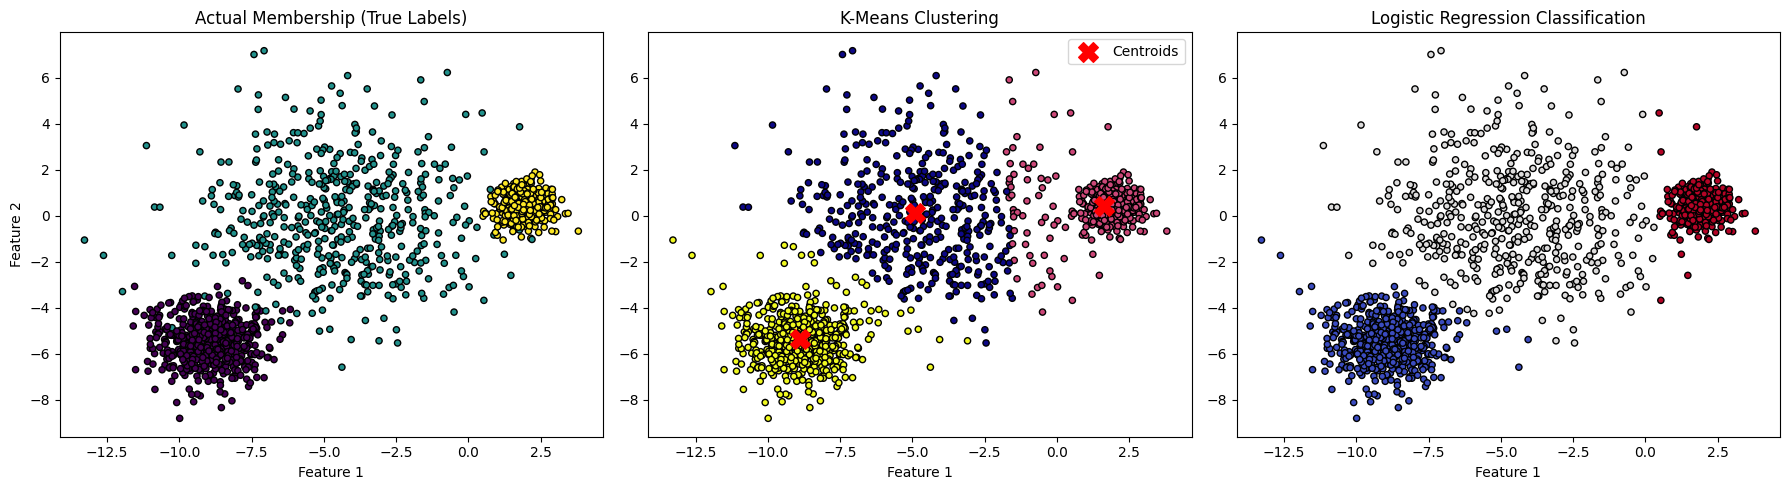

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# ১. K-Means Clustering মডেল তৈরি ও প্রেডিকশন
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# ২. Logistic Regression মডেল তৈরি ও প্রেডিকশন
# (মডেল ট্রেন করার জন্য ডেটাকে ট্রেন ও টেস্ট সেটে ভাগ করে নেওয়া ভালো)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log_reg = log_reg.predict(X) # পুরো ডেটাসেটের ওপর প্রেডিকশন (ভিজ্যুয়ালাইজেশনের জন্য)

# ৩. ভিজ্যুয়ালাইজেশন (Subplots তৈরি)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (ক) Actual Membership Plot
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', s=20)
axes[0].set_title("Actual Membership (True Labels)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")

# (খ) K-Means Clustering Plot
axes[1].scatter(X[:, 0], X[:, 1], c=y_kmeans, cmap='plasma', edgecolor='k', s=20)
axes[1].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
axes[1].set_title("K-Means Clustering")
axes[1].set_xlabel("Feature 1")
axes[1].legend()

# (গ) Logistic Regression Classification Plot
axes[2].scatter(X[:, 0], X[:, 1], c=y_pred_log_reg, cmap='coolwarm', edgecolor='k', s=20)
axes[2].set_title("Logistic Regression Classification")
axes[2].set_xlabel("Feature 1")

plt.tight_layout()
plt.show()

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=1e91bd54-be52-46c8-8e4a-baf88d675b91' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>